In [51]:
import numpy as np
import pandas as pd
import pypsa

import sys
from pathlib import Path
from typing import Any

sys.path.insert(0, str(Path("src")))

from src import network_builder
from src import util
from src import scenario_runner

In [52]:
# Initialize load and renewable profile data

load_data = pd.read_csv("data/clean_load.csv")
load_data["time_utc"] = pd.to_datetime(load_data["time_utc"], utc=True)
load_data = load_data.set_index("time_utc")

snapshots = load_data.index
nHours = len(snapshots)

load = pd.DataFrame(index=snapshots)
load["Region1"] = load_data["load_mw"] * .7
load["Region2"] = load_data["load_mw"] *  .5
load["Region3"] = load_data["load_mw"] * .3

wind_low, solar_low = util.load_trio_csv("data/low_correlation_trio_timeseries.csv")
wind_high, solar_high = util.load_trio_csv("data/high_correlation_trio_timeseries.csv")

In [53]:
# Make non-tz aware for PyPSA
snapshots = snapshots.tz_convert("UTC").tz_localize(None)
load.index = load.index.tz_convert("UTC").tz_localize(None)
wind_low.index = wind_low.index.tz_convert("UTC").tz_localize(None)
wind_high.index = wind_high.index.tz_convert("UTC").tz_localize(None)
solar_low.index = solar_low.index.tz_convert("UTC").tz_localize(None)
solar_high.index = solar_high.index.tz_convert("UTC").tz_localize(None)

correlation_cases = {
    "low": {
        "wind_cf": wind_low,
        "solar_cf": solar_low,
    },
    "high": {
        "wind_cf": wind_high,
        "solar_cf": solar_high,
    },
}

# Baseline annualized costs
ldes_capex_per_mw = 1_800_000
transmission_capex_per_mw = 400_000

In [55]:

rows: list[dict[str, Any]] = []

ldes_duration = 100
export_dir = "extension"

for co2_baseline_fraction in [0.05, 0.1, 0.2]:
    total_load_mwh = load.sum().sum()
    baseline_emissions = total_load_mwh * 0.4 #tCO2 / MWh
    co2_cap_tons = baseline_emissions * co2_baseline_fraction

    for corr_case, cf_dict in correlation_cases.items():
        wind_cf = cf_dict["wind_cf"]
        solar_cf = cf_dict["solar_cf"]

        scenario_id = f"corr_{corr_case}_co2frac_{co2_baseline_fraction}"

        metadata = {
            "renewable_correlation_case": corr_case,
            "co2_baseline_frac": co2_baseline_fraction,
            "ldes_duration_hours": ldes_duration,
            "ldes_capex_per_mw": ldes_capex_per_mw,
            "transmission_capex_per_mw": transmission_capex_per_mw,
            "co2_cap_tons": co2_cap_tons,
        }

        _, summary = scenario_runner.run_scenario(
            scenario_id=scenario_id,
            snapshots=snapshots,
            load=load,
            wind_cf=wind_cf,
            solar_cf=solar_cf,
            co2_cap_tons=co2_cap_tons,
            ldes_capex_per_mw=ldes_capex_per_mw,
            transmission_capex_per_mw=transmission_capex_per_mw,
            ldes_duration_hours=ldes_duration,
            export_dir=Path(export_dir) / scenario_id if export_dir else None,
            metadata=metadata,
        )
        rows.append(summary)

results = pd.DataFrame(rows).sort_values(
        ["renewable_correlation_case", "co2_baseline_frac"]
)
if export_dir is not None:
    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)
    results.to_csv(export_dir / "core_scenario_results.csv", index=False)

print(results.reset_index(drop=True))

/Users/birdo/Documents/GitHub/esm-capstone/src/scenario_runner.py:218: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 601.23it/s]
INFO:linopy.io: Writing time: 0.13s


Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-tgvj7wrv has 604459 rows; 262818 cols; 1272679 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+02]
  Cost    [4e+01, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [4e+03, 7e+06]
Presolving model
352862 rows, 247759 cols, 1006023 nonzeros  0s
Dependent equations search running on 68852 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
342874 rows, 237771 cols, 1100493 nonzeros  0s
Presolve reductions: rows 342874(-261585); columns 237771(-25047); nonzeros 1100493(-172186) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 26280(5.17479e+08); Du: 0(1.33997e-08) 0.5s
      32425     5.1740112957e+09 Pr: 23417(2.43376e+08); Du: 0(1.86063e-06) 5.9s
      37063     5.1740838066e+09 Pr: 23991(1.36449e+09); Du: 0(1.82391e-06) 11.8s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262818 primals, 604459 duals
Objective: 3.52e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-tgvj7wrv
Model status        : Optimal
Simplex   iterations: 435265
Objective value     :  3.5230777687e+10
P-D objective error :  2.6094855163e-14
HiGHS run time      :       1938.96


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.
/Users/birdo/Documents/GitHub/esm-capstone/src/scenario_runner.py:218: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████

...

Running HiGHS 1.13.1 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-e2ta5xly has 604459 rows; 262818 cols; 1273316 nonzeros
Coefficient ranges:
  Matrix  [1e-03, 1e+02]
  Cost    [4e+01, 2e+05]
  Bound   [0e+00, 0e+00]
  RHS     [4e+03, 3e+07]
Presolving model
353499 rows, 248396 cols, 1007934 nonzeros  0s
Dependent equations search running on 69293 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
343952 rows, 238849 cols, 1098197 nonzeros  0s
Presolve reductions: rows 343952(-260507); columns 238849(-23969); nonzeros 1098197(-175119) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 26280(5.24771e+08); Du: 0(1.34098e-08) 0.5s
      51006     5.8286244147e+09 Pr: 28851(2.49058e+08); Du: 0(1.81525e-06) 6.2s
      55328     6.3362601292e+09 Pr: 57181(9.56803e+08); Du: 0(2.32081e-06) 11.7s


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262818 primals, 604459 duals
Objective: 3.03e+10
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-e2ta5xly
Model status        : Optimal
Simplex   iterations: 402249
Objective value     :  3.0280917432e+10
P-D objective error :  1.1841832196e-14
HiGHS run time      :       1864.53


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


              scenario_id renewable_correlation_case  co2_baseline_frac  \
0  corr_high_co2frac_0.05                       high               0.05   
1   corr_high_co2frac_0.1                       high               0.10   
2   corr_high_co2frac_0.2                       high               0.20   
3   corr_low_co2frac_0.05                        low               0.05   
4    corr_low_co2frac_0.1                        low               0.10   
5    corr_low_co2frac_0.2                        low               0.20   

   ldes_duration_hours  ldes_capex_per_mw  transmission_capex_per_mw  \
0                  100            1800000                     400000   
1                  100            1800000                     400000   
2                  100            1800000                     400000   
3                  100            1800000                     400000   
4                  100            1800000                     400000   
5                  100            1800000 

In [56]:
from src import visualize_results
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
results_dir = Path(export_dir)
df = pd.read_csv(results_dir / "core_scenario_results.csv")

results = df.sort_values(
    ["renewable_correlation_case", "co2_baseline_frac"]
).reset_index(drop=True)

results.head()

,scenario_id,renewable_correlation_case,co2_baseline_frac,ldes_duration_hours,ldes_capex_per_mw,transmission_capex_per_mw,co2_cap_tons,solver_status,solver_condition,objective,...,transmission_capex_total,transmission_capex,wind_opex,solar_opex,backup_opex,generator_opex_total,total_capex,total_opex,reconstructed_total_cost,cost_reconstruction_error
0,corr_high_co2frac_0.05,high,0.05,100,1800000,400000,6.576568e+06,ok,optimal,3.953310e+10,...,1.015077e+09,1.015077e+09,0.0,0.0,7.398639e+08,7.398639e+08,3.879324e+10,7.398639e+08,3.953310e+10,0.003830
1,corr_high_co2frac_0.1,high,0.10,100,1800000,400000,1.315314e+07,ok,optimal,3.560977e+10,...,1.166718e+09,1.166718e+09,0.0,0.0,1.479728e+09,1.479728e+09,3.413004e+10,1.479728e+09,3.560977e+10,0.003220
2,corr_high_co2frac_0.2,high,0.20,100,1800000,400000,2.630627e+07,ok,optimal,3.028092e+10,...,1.082046e+09,1.082046e+09,0.0,0.0,2.959456e+09,2.959456e+09,2.732146e+10,2.959456e+09,3.028092e+10,-0.000874
3,corr_low_co2frac_0.05,low,0.05,100,1800000,400000,6.576568e+06,ok,optimal,3.523078e+10,...,1.220656e+09,1.220656e+09,0.0,0.0,7.398639e+08,7.398639e+08,3.449091e+10,7.398639e+08,3.523078e+10,-0.001724
4,corr_low_co2frac_0.1,low,0.10,100,1800000,400000,1.315314e+07,ok,optimal,3.285795e+10,...,1.164747e+09,1.164747e+09,0.0,0.0,1.479728e+09,1.479728e+09,3.137823e+10,1.479728e+09,3.285795e+10,-0.001339


In [57]:
def plot_co2_sensitivity_bars(
    results: pd.DataFrame,
    axes: tuple[plt.Axes, plt.Axes] | None = None,
) -> tuple[plt.Axes, plt.Axes]:

    needed = [
        "co2_baseline_frac",
        "renewable_correlation_case",
        "ldes_mw",
        "transmission_mw",
    ]

    missing = [c for c in needed if c not in results.columns]
    if missing:
        raise ValueError(f"Missing columns for CO₂ sensitivity plot: {missing}")

    df = results.copy()

    # Convert fractions to percentage labels
    df["co2_case"] = (
        (df["co2_baseline_frac"] * 100)
        .astype(int)
        .astype(str)
        + "%"
    )

    # Sort x-axis
    order = ["5%", "10%", "20%"]

    if axes is None:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(11, 4.8),
            constrained_layout=True,
        )

    ax1, ax2 = axes

    # -----------------------------
    # LDES Capacity Plot
    # -----------------------------
    sns.barplot(
        data=df,
        x="co2_case",
        y="ldes_mw",
        hue="renewable_correlation_case",
        order=order,
        ax=ax1,
    )

    ax1.set_title("LDES Deployment")
    ax1.set_xlabel("CO2 Cap (% of Gas-Only Baseline)")
    ax1.set_ylabel("LDES Capacity (MW)")
    ax1.set_ylim(bottom=0)

    ax1.grid(True, axis="y", alpha=0.25)
    ax1.grid(False, axis="x")

    # -----------------------------
    # Transmission Capacity Plot
    # -----------------------------
    sns.barplot(
        data=df,
        x="co2_case",
        y="transmission_mw",
        hue="renewable_correlation_case",
        order=order,
        ax=ax2,
    )

    ax2.set_title("Transmission Deployment")
    ax2.set_xlabel("CO2 Cap (% of Gas-Only Baseline)")
    ax2.set_ylabel("Transmission Capacity (MW)")
    ax2.set_ylim(bottom=0)

    ax2.grid(True, axis="y", alpha=0.25)
    ax2.grid(False, axis="x")

    # Remove duplicate legend
    ax2.get_legend().remove()

    # Single shared legend
    ax1.legend(
        title="Correlation Case",
        frameon=True,
        loc="upper right",
    )

    return ax1, ax2

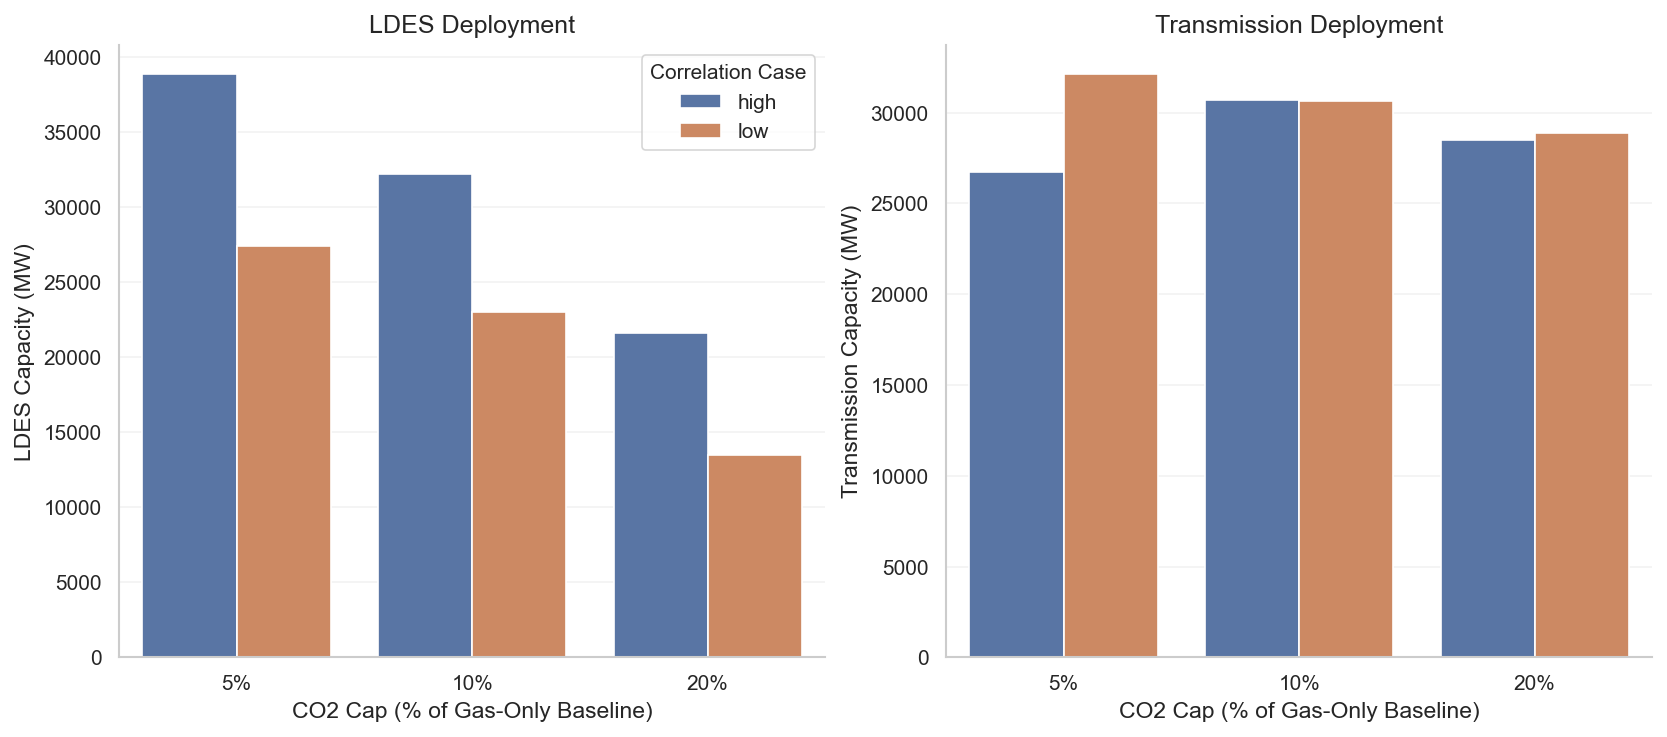

In [58]:
visualize_results.set_paper_style()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    constrained_layout=True,
)

plot_co2_sensitivity_bars(results, axes=axes)

fig.savefig(
    "figures/extension/slides_co2_sensitivity.png",
    bbox_inches="tight",
)

plt.show()

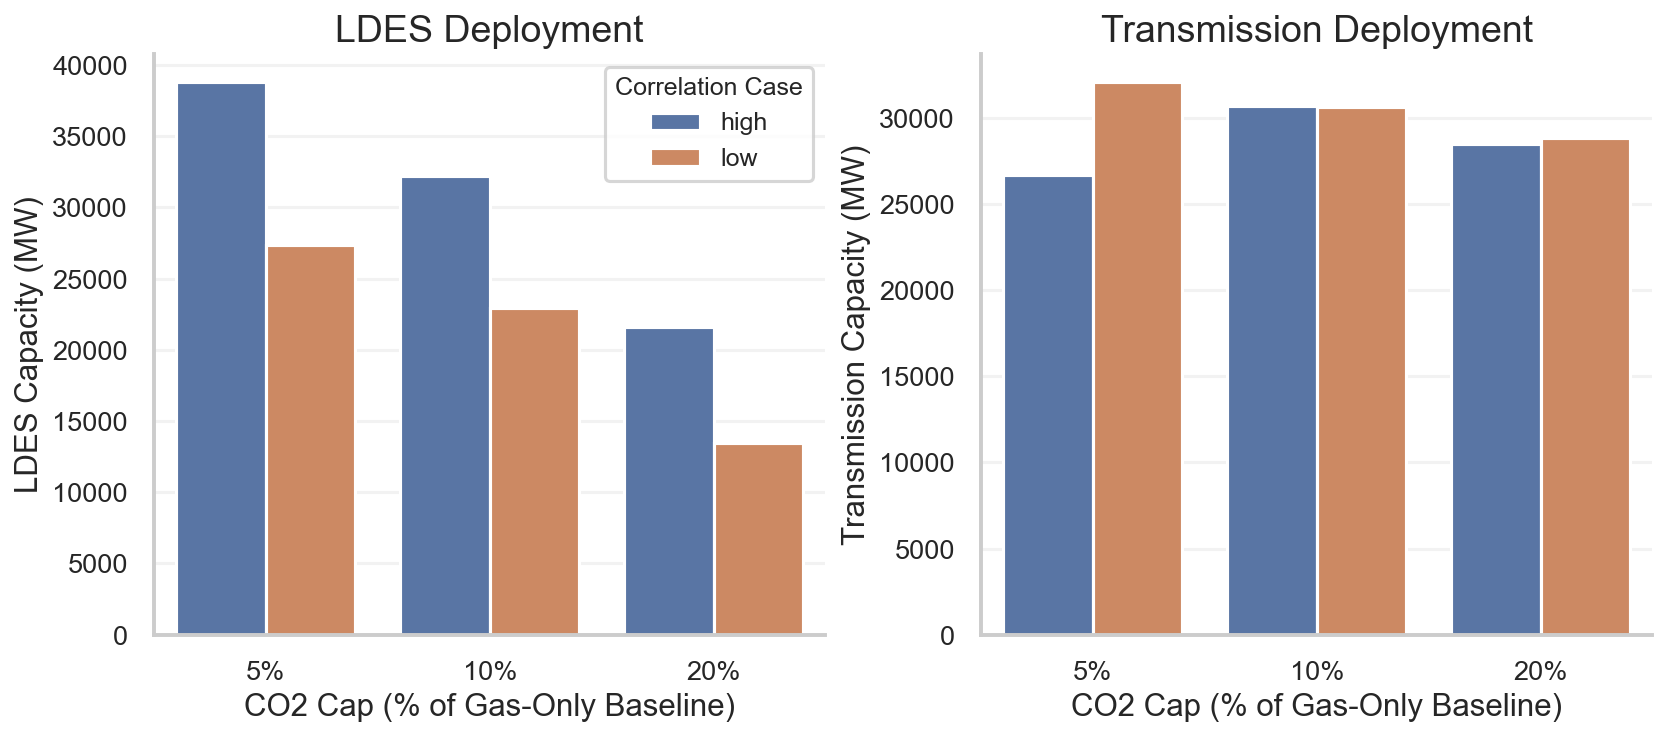

In [59]:
visualize_results.set_slide_style()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    constrained_layout=True,
)

plot_co2_sensitivity_bars(results, axes=axes)

fig.savefig(
    "figures/extension/paper_co2_sensitivity.png",
    bbox_inches="tight",
)

plt.show()